<a href="https://colab.research.google.com/github/gilad-altshuler/Three_Body_RNN/blob/main/notebooks/5_Neural_recordings_inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys, os
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Running in Colab. Cloning repo...")
    !git clone https://github.com/gilad-altshuler/Three_Body_RNN
    %cd Three_Body_RNN
    ROOT = Path(".").resolve()

    # Load Arial font
    !wget -O Arial.ttf "https://github.com/matomo-org/travis-scripts/raw/master/fonts/Arial.ttf"

else:
    print("Not running in Colab.")
    ROOT = Path(__file__).resolve().parent.parent
    sys.path.append(str(ROOT))
    sys.path.insert(0, str(ROOT.parent / "lowrank_inference"))

Running in Colab. Cloning repo...
Cloning into 'Three_Body_RNN'...
remote: Enumerating objects: 1423, done.
remote: Counting objects: 100% (171/171), done.
remote: Compressing objects: 100% (121/121), done.
remote: Total 1423 (delta 91), reused 85 (delta 46), pack-reused 1252 (from 2)
Receiving objects: 100% (1423/1423), 485.42 MiB | 24.17 MiB/s, done.
Resolving deltas: 100% (770/770), done.
/content/Three_Body_RNN
--2025-09-26 12:29:00--  https://github.com/matomo-org/travis-scripts/raw/master/fonts/Arial.ttf
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/matomo-org/travis-scripts/master/fonts/Arial.ttf [following]
--2025-09-26 12:29:00--  https://raw.githubusercontent.com/matomo-org/travis-scripts/master/fonts/Arial.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133

In [2]:
import torch
import random
from torch import nn
import numpy as np
import copy
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
%matplotlib inline
if IN_COLAB:
  fm.fontManager.addfont('Arial.ttf')
  arial_fp = fm.FontProperties(fname='Arial.ttf')
  plt.rcParams['font.family'] = arial_fp.get_name()
else:
  plt.rcParams['font.family'] = 'Arial'
plt.rcParams["font.size"] = 10
import seaborn as sns

In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [4]:
SEED = 3150
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [5]:
rec_all = {}

# Mante-inference

In [6]:
DATA_DIR = ROOT / "data" / "mante_inference"
FIG_DIR = ROOT / "notebooks" / "figures"

In [7]:
import pickle
with open(DATA_DIR / "r2s.pkl", "rb") as f:
    r2s = pickle.load(f)

In [8]:
samples = len(r2s['test']['hornn'])
ranks = 5

modes = ['train','valid','test']
models = ["RNN", "HORNN"]
for m in modes:
  r2s[m]['hornn'] = r2s[m]['hornn'].reshape(1,samples).repeat(ranks,axis=0)

In [9]:
ref = 'HORNN'

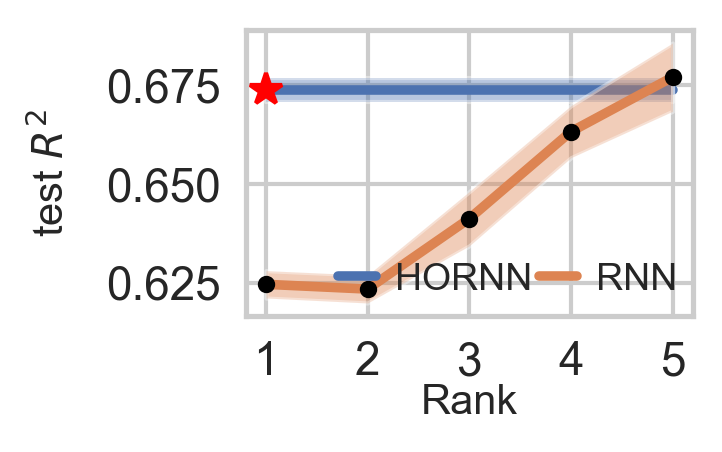

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Theme FIRST (applies to objects created after this line)
sns.set_theme(style="whitegrid", font_scale=1)

# Prepare data
r = np.arange(1, ranks + 1)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(2.5, 2/3*2.5), dpi=300)

records = []
for model in models:
    mean = np.mean(r2s[m][model.lower()], axis=-1)
    ste  = np.std(r2s[m][model.lower()], axis=-1) / (samples**0.5)
    d_err, u_err = mean - ste, mean + ste
    for i in range(ranks):
        records.append({
            "Rank": r[i],
            "Metric": mean[i],
            "u_err": u_err[i],
            "d_err": d_err[i],
            "Model": model
        })

rec_all[r"Mante|$R^2$"] = (records, ref)

df = pd.DataFrame(records)

# Plot each model with ribbon
for model, sub in df.groupby("Model"):
    sns.lineplot(ax=ax, data=sub, x="Rank", y="Metric", linestyle="--" if model.lower() == ref else "-",
                  label=model,
                  linewidth=2.3, zorder=1)
    ax.fill_between(sub["Rank"], sub["d_err"], sub["u_err"], alpha=0.4,linestyle="--" if model.lower() == ref else "-")
    if model == ref:
      ax.plot(sub["Rank"].iloc[0],sub["Metric"].iloc[0],'*', ms=8, color='red')
    else:
      ax.scatter(sub["Rank"], sub["Metric"], s=10, color="black", zorder=2)

# Labels and formatting
ax.set_xlabel("Rank", fontsize=10, labelpad=0)
ax.set_ylabel(fr"{m} $R^2$", fontsize=10, labelpad=8)
ax.set_xticks(np.arange(1, ranks + 1))
ax.tick_params(axis='both', which='major', pad=0)  # avoid negative pad
ax.grid(True)  # ensure grid even if theme changes

# Legend on the last axes
ax.legend(frameon=False, fontsize=9, loc='lower right',
                bbox_to_anchor=(1.04, -0.05), ncol=2,
                columnspacing=0.2, handletextpad=0.5, handlelength=1.0)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/mante.png", dpi=300, bbox_inches='tight')
plt.show()


# Reach-inference

## Reach-Neural Latent benchmark (NLB) evaluation

In [11]:
DATA_DIR = ROOT / "data" / "reach_inference" / "reach_nlb"
FIG_DIR = ROOT / "notebooks" / "figures"

In [12]:
import pickle
with open(DATA_DIR / "metrics.pkl", "rb") as f:
    metrics = pickle.load(f)

In [13]:
samples = 30
for metric_name, metric in metrics.items():
  print(metric_name,":")
  for key,val in metric.items():
    ste = val.std()/(samples**0.5)
    mean = val.mean()
    print(key,f"mean: {mean} ",mean+ste,mean-ste)

co-bps :
r_36_rnn mean: 0.340324112693544  0.3406361248570402 0.3400121005300478
r_34_r_1_hornn mean: 0.33961739444222344  0.33989845505348437 0.3393363338309625
r_35_r_1_hornn mean: 0.3411370967962189  0.3414455957370331 0.3408285978554047
r_36_r_1_hornn mean: 0.34221151016344387  0.34248617096428746 0.34193684936260027
fp-bps :
r_36_rnn mean: 0.2356572054121798  0.23609056618879462 0.23522384463556498
r_34_r_1_hornn mean: 0.23585041210488905  0.23633761044921314 0.23536321376056496
r_35_r_1_hornn mean: 0.2363950539468117  0.23692317557938405 0.23586693231423936
r_36_r_1_hornn mean: 0.23763784419210016  0.23800878883156223 0.23726689955263808
psth R2 :
r_36_rnn mean: 0.5738130809131708  0.5759833079394848 0.5716428538868569
r_34_r_1_hornn mean: 0.5770999175397701  0.5787756067084576 0.5754242283710825
r_35_r_1_hornn mean: 0.5790081439488127  0.5804915834715156 0.5775247044261098
r_36_r_1_hornn mean: 0.5791659505142728  0.5804758483403947 0.5778560526881509
vel R2 :
r_36_rnn mean: 0.88

In [14]:
samples = 30
ranks = (34,35,36)
metric_names = list(metrics.keys())
models = ["RNN", "HORNN"]
for m in metric_names:
  metrics[m]['RNN'] = metrics[m]['r_36_rnn'].reshape(1,samples).repeat(len(ranks),axis=0)
  metrics[m]['HORNN'] = np.stack([metrics[m][f'r_{r}_r_1_hornn'] for r in ranks],axis=0)

pretty = {"co-bps":"co-bps", "fp-bps":"fp-bps",
          "psth R2": r"psth $R^2$", "vel R2": r"vel $R^2$"}

In [15]:
ref = 'RNN'

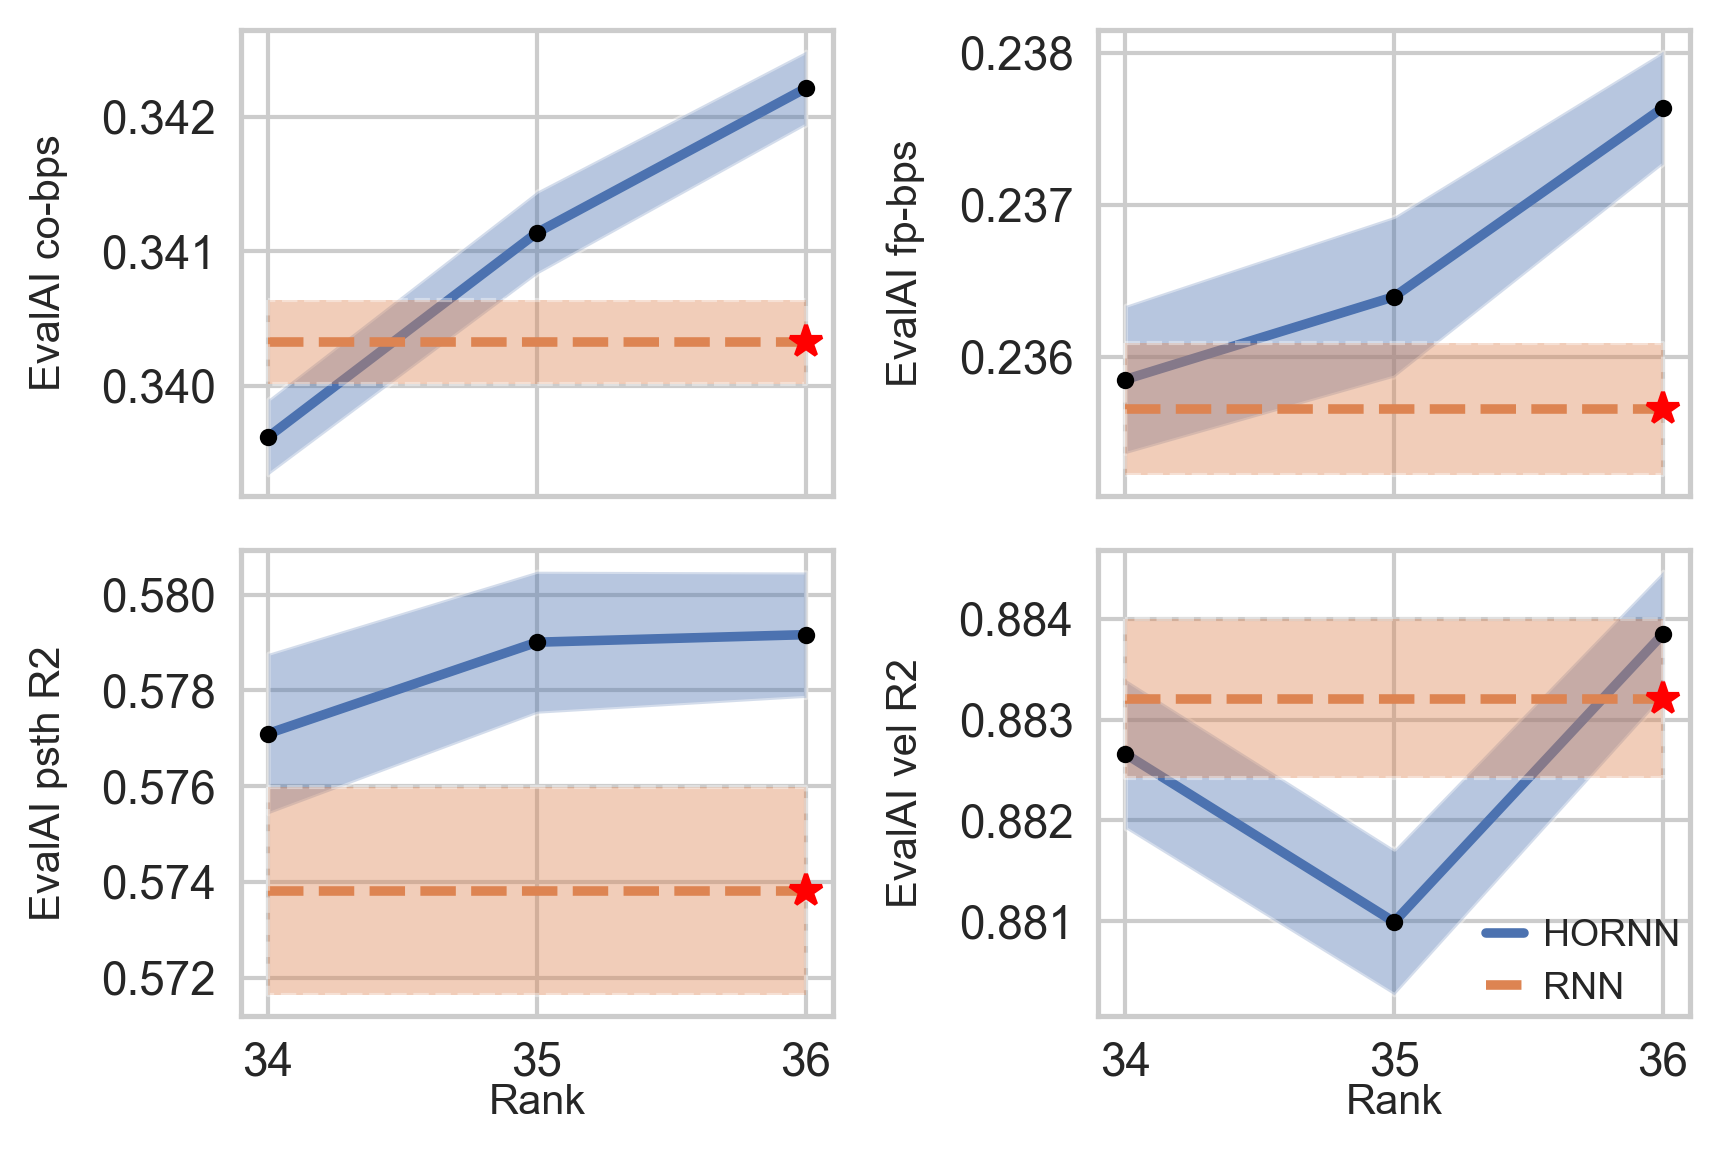

In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Theme FIRST (applies to objects created after this line)
sns.set_theme(style="whitegrid", font_scale=1)

# Prepare data
r = ranks

# Plot
fig, axes = plt.subplots(2, 2, figsize=(6, 4), dpi=300, sharex=True)

for ax, m in zip(axes.flatten(), metric_names):

    records = []
    for model in models:
        mean = np.mean(metrics[m][model], axis=-1)
        ste  = np.std(metrics[m][model], axis=-1) / (samples**0.5)
        d_err, u_err = mean - ste, mean + ste
        for i in range(len(ranks)):
            records.append({
                "Rank": r[i],
                "Metric": mean[i],
                "u_err": u_err[i],
                "d_err": d_err[i],
                "Model": model
            })

    rec_all[fr"NLB reach|{pretty[m]}"] = (records, ref)

    df = pd.DataFrame(records)

    # Plot each model with ribbon
    for model, sub in df.groupby("Model"):
        sns.lineplot(ax=ax, data=sub, x="Rank", y="Metric", linestyle="--" if model == ref else "-",
                     label=model if ax is axes.flatten()[-1] else None,
                     linewidth=2.3, zorder=1)
        ax.fill_between(sub["Rank"], sub["d_err"], sub["u_err"], alpha=0.4, linestyle="--" if model == ref else "-",)
        if model == ref:
          ax.plot(sub["Rank"].iloc[-1],sub["Metric"].iloc[-1],'*', ms=8, color='red')
        else:
          ax.scatter(sub["Rank"], sub["Metric"], s=10, color="black", zorder=2)

    # Labels and formatting
    ax.set_xlabel("Rank", fontsize=10, labelpad=0)
    ax.set_ylabel(f"EvalAI {m}", fontsize=10, labelpad=8)
    ax.set_xticks(ranks)
    ax.tick_params(axis='both', which='major', pad=0)  # avoid negative pad
    ax.grid(True)  # ensure grid even if theme changes

# Legend on the last axes
axes.flatten()[-1].legend(frameon=False, fontsize=9, loc='lower right',
                bbox_to_anchor=(1.04, -0.05),
                columnspacing=0.2, handletextpad=0.5, handlelength=1.0)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/reach_nlb_EvalAI.png", dpi=300, bbox_inches='tight')
plt.show()


## Reach-conditioning

In [17]:
DATA_DIR = ROOT / "data" / "reach_inference" / "reach_condition"
FIG_DIR = ROOT / "notebooks" / "figures"

In [18]:
import pickle
with open(DATA_DIR / "r2s.pkl", "rb") as f:
    r2s = pickle.load(f)

In [19]:
samples = 30
for key,val in r2s.items():
  ste = val.std()/(samples**0.5)
  mean = val.mean()
  print(key,f"mean: {mean} ",mean+ste,mean-ste)

r_5_rnn mean: 0.8770258645216624  0.8834207529300604 0.8706309761132645
r_6_rnn mean: 0.911115288734436  0.9119042517805274 0.9103263256883447
r_4_r_1_hornn mean: 0.880584587653478  0.8858070559201402 0.8753621193868159
r_5_r_1_hornn mean: 0.9092502911885579  0.910022932050774 0.9084776503263419
r_6_r_1_hornn mean: 0.9127869188785553  0.9133642784250717 0.912209559332039


In [20]:
samples = 30
ranks = (4,5,6)
metric_names = ['vel $R^2$',]
models = ["RNN", "HORNN"]
r2s['RNN'] = r2s['r_6_rnn'].reshape(1,samples).repeat(len(ranks),axis=0)
r2s['HORNN'] = np.stack([r2s[f'r_{r}_r_1_hornn'] for r in ranks],axis=0)

In [21]:
ref = 'RNN'

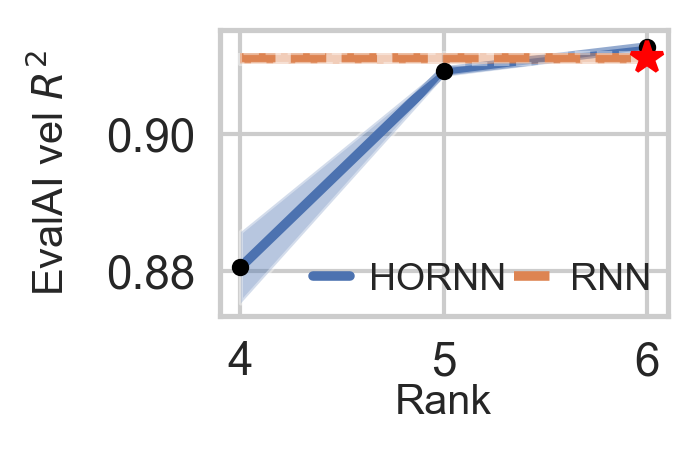

In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Theme FIRST (applies to objects created after this line)
sns.set_theme(style="whitegrid", font_scale=1)

# Prepare data
r = ranks

# Plot
fig, axes = plt.subplots(1, 1, figsize=(2.5, 2/3*2.5), dpi=300)

for ax, m in zip([axes,], metric_names):

    records = []
    for model in models:
        mean = np.mean(r2s[model], axis=-1)
        ste  = np.std(r2s[model], axis=-1) / (samples**0.5)
        d_err, u_err = mean - ste, mean + ste
        for i in range(len(ranks)):
            records.append({
                "Rank"   : r[i],
                "Metric" : mean[i],
                "u_err"  : u_err[i],
                "d_err"  : d_err[i],
                "Model"  : model
            })
    rec_all[r"Reach conditioning|vel $R^2$"] = (records, ref)
    df = pd.DataFrame(records)

    # Plot each model with ribbon
    for model, sub in df.groupby("Model"):
        sns.lineplot(ax=ax, data=sub, x="Rank", y="Metric",
                     label=model, linestyle="--" if model == ref else "-",
                     linewidth=2.3, zorder=1)
        ax.fill_between(sub["Rank"], sub["d_err"], sub["u_err"], alpha=0.4, linestyle="--" if model == ref else "-",)
        if model == ref:
          ax.plot(sub["Rank"].iloc[-1],sub["Metric"].iloc[-1],'*', ms=8, color='red')
        else:
          ax.scatter(sub["Rank"], sub["Metric"], s=10, color="black", zorder=2)

    # Labels and formatting
    ax.set_xlabel("Rank", fontsize=10, labelpad=0)
    ax.set_ylabel(f"EvalAI {m}", fontsize=10, labelpad=8)
    ax.set_xticks(ranks)
    ax.tick_params(axis='both', which='major', pad=0)  # avoid negative pad
    ax.grid(True)  # ensure grid even if theme changes

# Legend on the last axes
axes.legend(frameon=False, fontsize=9, loc='lower right',
                bbox_to_anchor=(1.04, -0.05), ncol=2,
                columnspacing=0.2, handletextpad=0.5, handlelength=1.0)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/reach_conditioning.png", dpi=300, bbox_inches='tight')
plt.show()


# Create unifying figure

/tmp/ipython-input-520192573.py:96: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


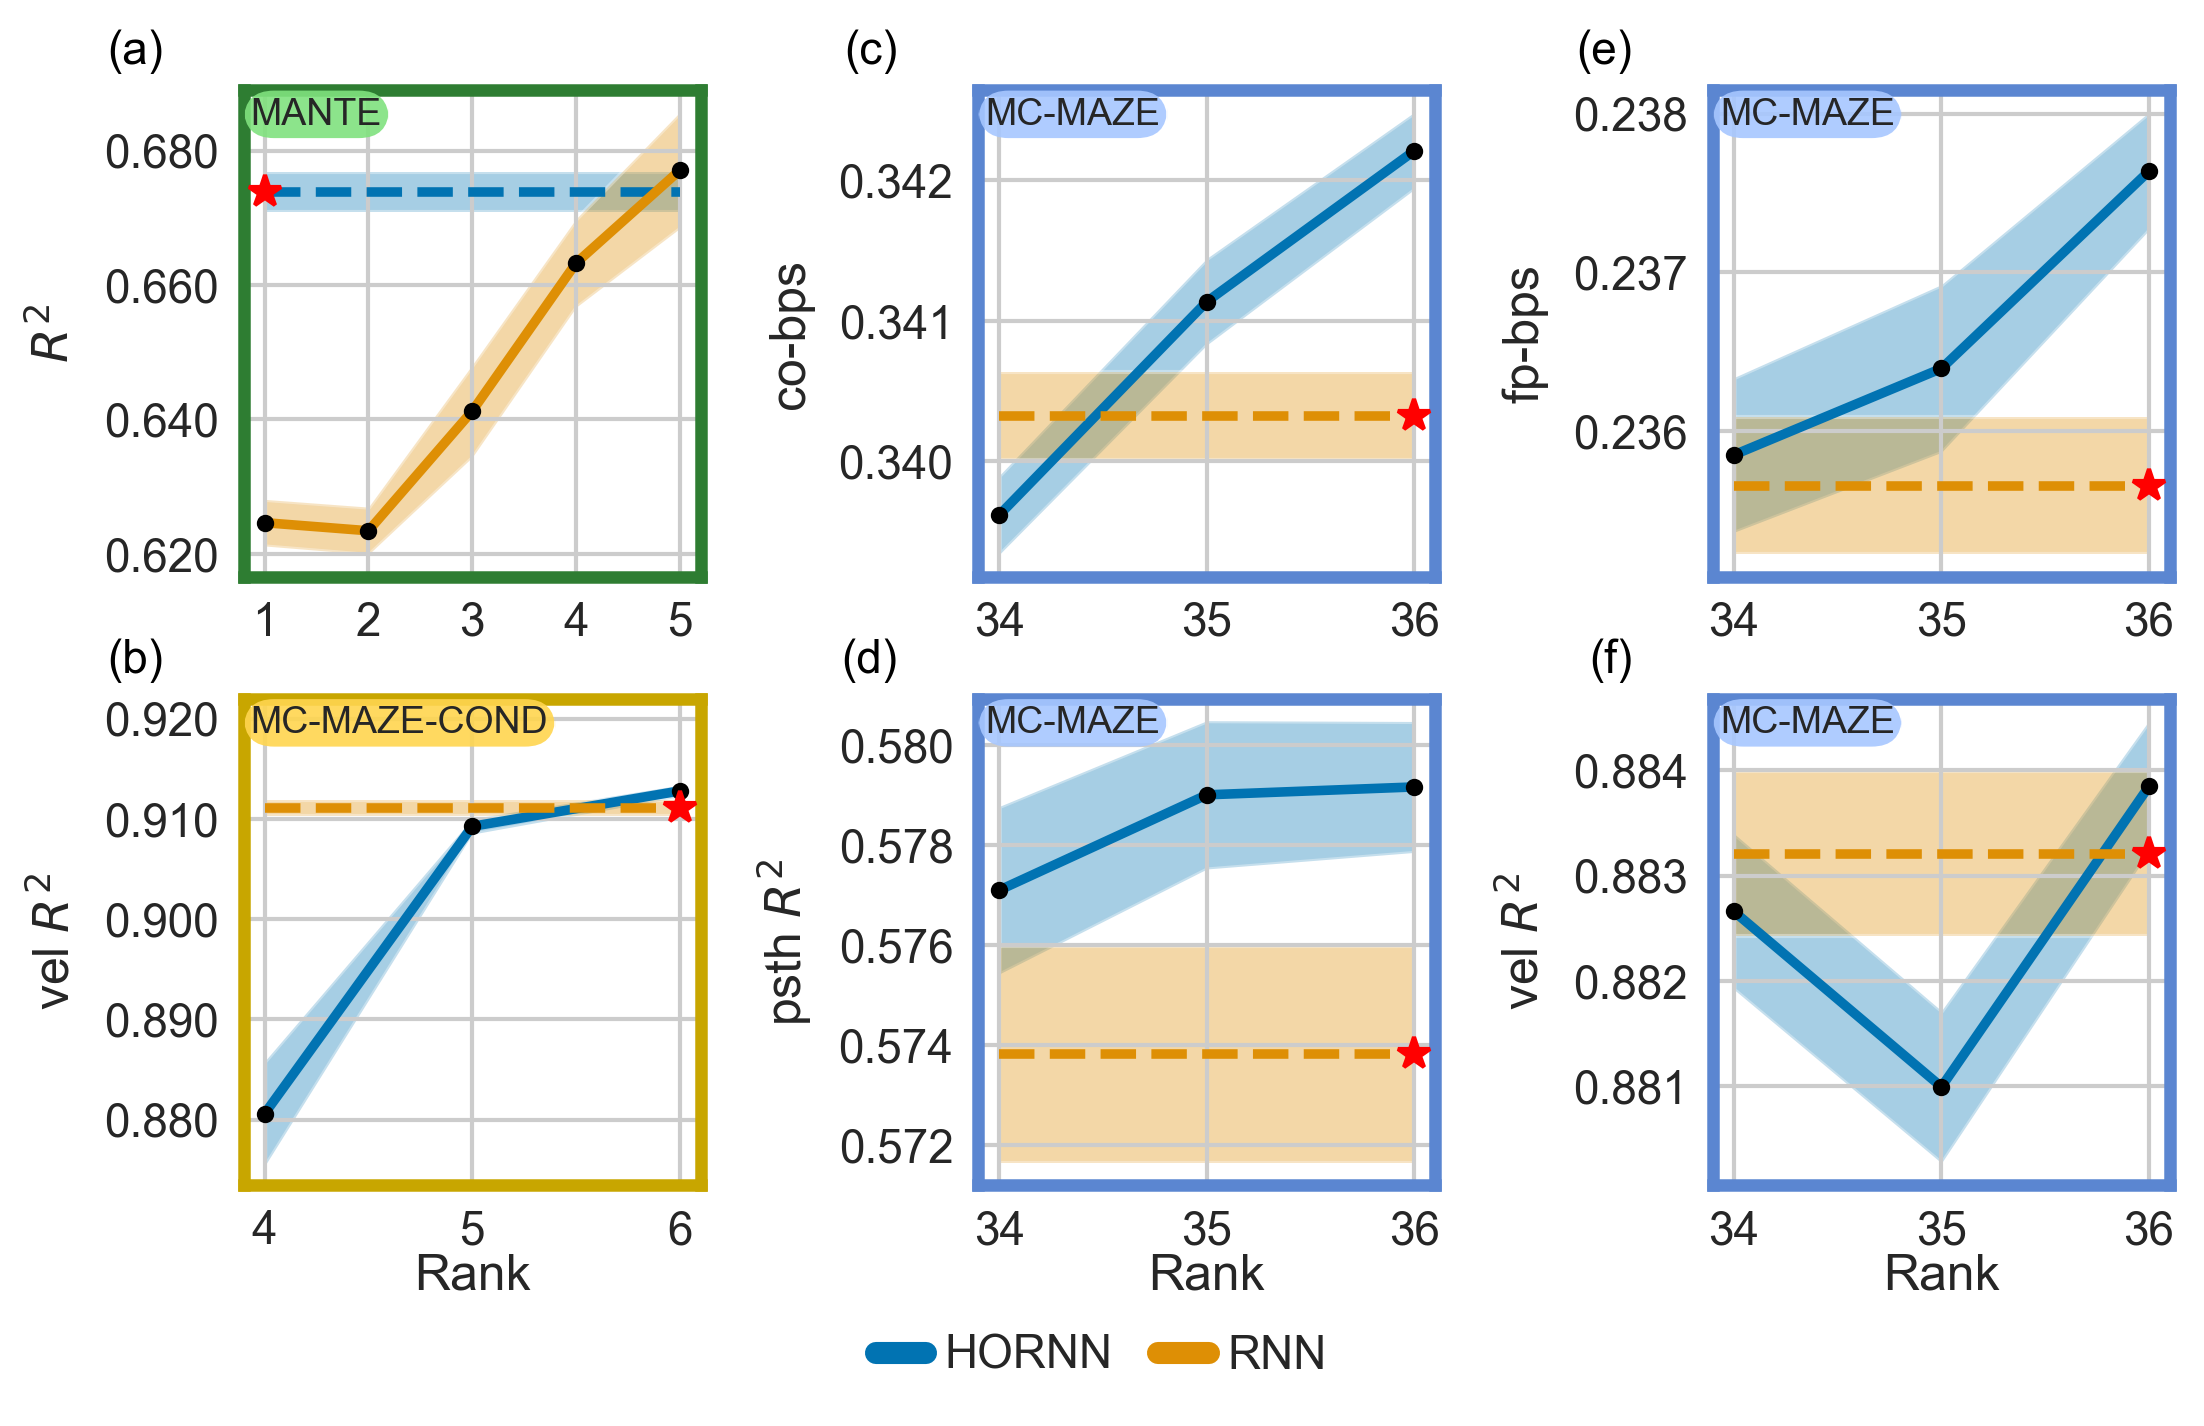

In [23]:
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
SHOW_YLABELS_ALL = True

from matplotlib.patches import Patch
from matplotlib.transforms import Bbox

# ---------- task look ----------
TASK_STYLE = {
    "NLB reach":          dict(badge="#A7C7FF", spine="#5B86D1", badge_text="MC-MAZE"),
    "Reach conditioning": dict(badge="#FFD54F", spine="#C8A600", badge_text="MC-MAZE-COND"),
    "Mante":              dict(badge="#80E27E", spine="#2E7D32", badge_text="MANTE"),
}
SHOW_BADGES = True           # set False to remove badges
SPINE_LINEWIDTH = 3        # “bold” spines

def _decorate_task(ax, task):
    """Bold colored spines (no background tint). Optional small badge."""
    st = TASK_STYLE[task]
    for side in ("left", "right", "top", "bottom"):
        ax.spines[side].set_color(st["spine"])
        ax.spines[side].set_linewidth(SPINE_LINEWIDTH)
    if SHOW_BADGES:
        ax.text(0.015, 0.985, st["badge_text"], transform=ax.transAxes,
                va="top", ha="left", fontsize=9, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.18,rounding_size=0.8",
                          facecolor=st["badge"], edgecolor="none", alpha=0.9))

def _plot_panel(task, ax, records, ref, models, palette, ylabel, show_xlabel):
    df = pd.DataFrame(records)
    for model, sub in df.groupby("Model"):
        c  = palette[model]
        ls = "--" if model.lower() == ref.lower() else "-"
        sns.lineplot(ax=ax, data=sub, x="Rank", y="Metric",
                     linewidth=2.3, zorder=1, linestyle=ls, color=c, legend=False)
        ax.fill_between(sub["Rank"].to_numpy(),
                        sub["d_err"].to_numpy(),
                        sub["u_err"].to_numpy(), alpha=0.35, zorder=0,
                        facecolor=c, edgecolor=None)
        if model.lower() == ref.lower():
            idx = -1 if ref.lower()=='rnn' else 0
            ax.plot(sub["Rank"].iloc[idx], sub["Metric"].iloc[idx],
                    marker="*", ms=8, color="red", zorder=3)
        else:
            ax.scatter(sub["Rank"], sub["Metric"], s=10, color="black", zorder=2)

    ax.set_ylabel(ylabel, fontsize=12, labelpad=6)
    if show_xlabel: ax.set_xlabel("Rank", fontsize=12, labelpad=0)
    else:            ax.set_xlabel("")
    ax.set_xticks(np.unique(df["Rank"]))
    if task == 'Reach conditioning': ax.set_ylim(top=0.922)
    ax.tick_params(axis='both', which='major', pad=0)
    ax.grid(True)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.3f'))

def make_six_panel(rec_all, models, savepath):
    """
    rec_all keys expected:
      r"Mante|$R^2$",
      r"Reach conditioning|$R^2$",
      "NLB reach|co-bps", "NLB reach|fp-bps",
      r"NLB reach|psth $R^2$", r"NLB reach|vel $R^2$"
    """
    # ---- desired layout (row-major) ----
    order_grid = [
        [r"Mante|$R^2$",             "NLB reach|co-bps",     "NLB reach|fp-bps"],      # row 0
        [r"Reach conditioning|vel $R^2$", r"NLB reach|psth $R^2$", r"NLB reach|vel $R^2$"],  # row 1
    ]
    order = [k for row in order_grid for k in row]

    sns.set_theme(style="whitegrid", font_scale=1)
    base = sns.color_palette("colorblind", n_colors=max(3, len(models)))
    palette = {m: base[i] for i, m in enumerate(models)}

    fig, axes = plt.subplots(2, 3, figsize=(7.5, 4.39), dpi=300, constrained_layout=True)
    axes = axes.flatten()

    for i, key in enumerate(order):
        task, metric = key.split("|", 1)
        records, ref  = rec_all[key]
        _plot_panel(task, axes[i], records, ref, models, palette,
                    ylabel=fr"{metric}",
                    show_xlabel=(i >= 3))

        _decorate_task(axes[i], task)  # <-- bold spines only

        if (not SHOW_YLABELS_ALL) and (i % 3 != 0):
            axes[i].set_ylabel("")

    # Global model legend (bottom)
    handles = [axes[-1].plot([], [], color=palette[m], linewidth=5.3, label=m)[0] for m in models]
    fig.legend(handles, [h.get_label() for h in handles],
               ncol=len(models), frameon=False, loc="lower center",
               bbox_to_anchor=(0.5, -0.05), handlelength=1.1,
               columnspacing=1.0, handletextpad=0.4)
    plt.tight_layout()

    # Put (a)…(f) outside, above-left of each axes
    DX, DY = 0.036, 0.012  # tweak offsets in figure coords
    letters = [f"({chr(97+2*i)})" for i in range(len(axes)//2)] + [f"({chr(98+2*i)})" for i in range(len(axes)//2)]  # (a)…(f)
    for i, ax in enumerate(axes):
        pos  = ax.get_position()
        task = order[i].split("|", 1)[0]  # color by task (optional)
        plt.gcf().text(pos.x0 - DX, pos.y1 + DY, letters[i],
                      ha="right", va="bottom", fontsize=11, fontweight="bold",
                      color='black')

    plt.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.show()

models = ["HORNN", "RNN"]
make_six_panel(rec_all, models, f"{FIG_DIR}/All_neural_rec_tasks_panel.png")


In [24]:
# Check the image proportions
from PIL import Image

# Load image
img = Image.open(f"{FIG_DIR}/All_neural_rec_tasks_panel.png")

# Get pixel dimensions
width_px, height_px = img.size
print(f"Pixel dimensions: {width_px} × {height_px} pixels")

# Get DPI info (if embedded)
dpi = img.info.get('dpi', (300, 300))  # Default fallback to 300
print(f"DPI: {dpi[0]} x {dpi[1]}")

# Convert to inches
width_in = width_px / dpi[0]
height_in = height_px / dpi[1]
print(f"Size in inches: {float(width_in):.2f} × {float(height_in):.2f} inches")

Pixel dimensions: 2204 × 1426 pixels
DPI: 299.9994 x 299.9994
Size in inches: 7.35 × 4.75 inches
